<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/maya-encoding/blob/main/examples/05_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VFD for Fraud Detection: Multi-Scale Amount Decomposition

This notebook demonstrates how **Vigesimal Feature Decomposition (VFD)** can improve fraud detection by decomposing transaction amounts into multi-scale features.

**Key insight:** Legitimate transactions tend to have structured amounts — ATMs dispense multiples of 20, retail prices end in .99/.95/.00, transfers are round numbers. Fraudulent transactions often break these patterns. VFD's bars/dots decomposition captures this structure automatically.

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) (Kaggle) — sampled to ~14.5k transactions (492 fraud).

In [2]:
!pip install maya-encoding==0.2.1 matplotlib

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from maya_encoding import VFDEncoder

np.random.seed(42)

## 1. Load and Explore the Data

In [4]:
import os

def generate_synthetic_fraud_data(n_legit=5000, n_fraud=300, seed=42):
    """Generate synthetic credit card fraud data when Kaggle is unavailable."""
    rng = np.random.RandomState(seed)
    n_total = n_legit + n_fraud

    # PCA-like features (V1-V28)
    V_legit = rng.randn(n_legit, 28)
    V_fraud = rng.randn(n_fraud, 28) * 1.5 + rng.choice([-1, 1], size=(n_fraud, 28)) * 0.8
    V = np.vstack([V_legit, V_fraud])

    # Amount: legit tends to be structured (round numbers), fraud more varied
    amt_legit = np.abs(rng.choice([10, 20, 25, 50, 100, 200, 500], n_legit).astype(float)
                       + rng.randn(n_legit) * 5)
    amt_fraud = np.abs(rng.exponential(500, n_fraud) + rng.randn(n_fraud) * 50)
    amounts = np.concatenate([amt_legit, amt_fraud])

    labels = np.array([0] * n_legit + [1] * n_fraud)

    cols = {f'V{i}': V[:, i-1] for i in range(1, 29)}
    cols['Amount'] = amounts
    cols['Class'] = labels

    return pd.DataFrame(cols)

# Try Kaggle download, fall back to synthetic data
if os.path.exists('data/creditcard_sampled.csv'):
    df = pd.read_csv('data/creditcard_sampled.csv')
    print('Loaded cached data from data/creditcard_sampled.csv')
else:
    try:
        import kagglehub, csv, random
        random.seed(42)
        os.makedirs('data', exist_ok=True)
        path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
        src = os.path.join(path, 'creditcard.csv')
        fraud, legit = [], []
        with open(src) as f:
            reader = csv.reader(f)
            header = next(reader)
            for row in reader:
                if row[-1] == '1': fraud.append(row)
                elif random.random() < 0.05: legit.append(row)
        with open('data/creditcard_sampled.csv', 'w', newline='') as f:
            w = csv.writer(f)
            w.writerow(header)
            w.writerows(fraud + legit)
        df = pd.read_csv('data/creditcard_sampled.csv')
        print(f'Downloaded from Kaggle: {len(fraud)} fraud + {len(legit)} legit')
    except Exception as e:
        print(f'Kaggle unavailable ({e}), using synthetic data...')
        df = generate_synthetic_fraud_data()
        print(f'Generated synthetic dataset')

print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["Class"].mean():.2%}')
print(f'\nAmount stats:')
print(df['Amount'].describe().round(2))

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Downloaded from Kaggle: 492 fraud + 14073 legit
Shape: (14565, 31)
Fraud rate: 3.38%

Amount stats:
count    14565.00
mean        90.63
std        246.05
min          0.00
25%          5.00
50%         20.48
75%         77.55
max       7429.15
Name: Amount, dtype: float64


## 2. Amount Distribution: Fraud vs Legitimate

Let's visualize how transaction amounts differ between fraud and legitimate transactions.

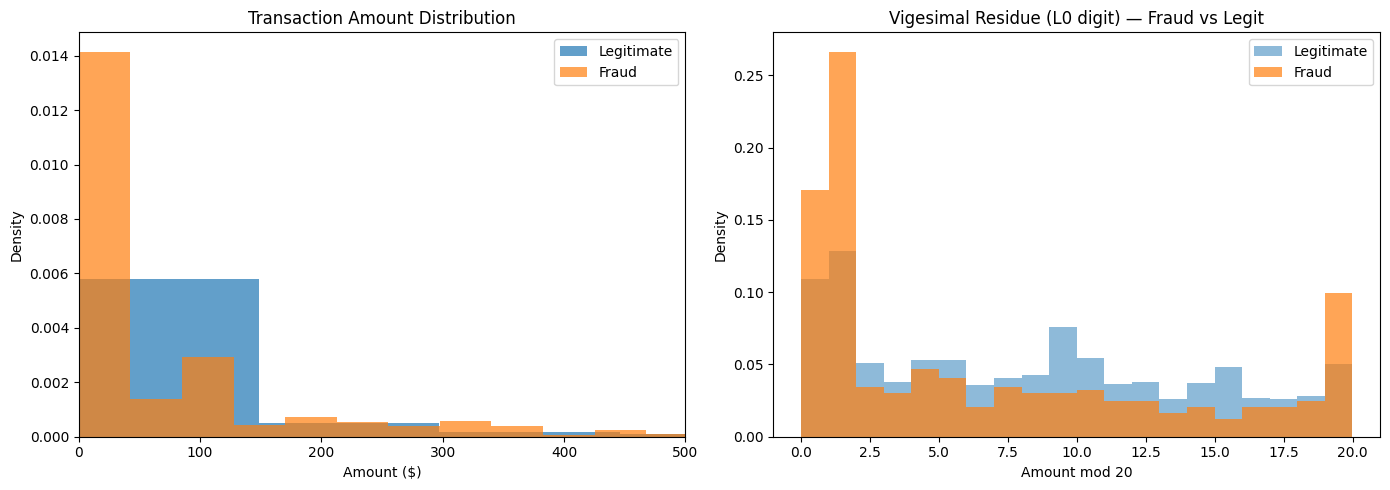

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Legitimate', density=True)
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', density=True)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Amount mod 20 ("vigesimal residue") — this is what VFD's L0 digit captures
for cls, label, alpha in [(0, 'Legitimate', 0.5), (1, 'Fraud', 0.7)]:
    amounts = df[df['Class']==cls]['Amount']
    mod20 = (amounts % 20).astype(float)
    axes[1].hist(mod20, bins=20, alpha=alpha, label=label, density=True)

axes[1].set_xlabel('Amount mod 20')
axes[1].set_ylabel('Density')
axes[1].set_title('Vigesimal Residue (L0 digit) — Fraud vs Legit')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. VFD Decomposition of Amount

Let's see what VFD does to a transaction amount. The decomposition reveals multi-scale structure that a flat number hides.

In [6]:
# Show VFD decomposition of example amounts
example_amounts = np.array([[100], [99.99], [347], [20], [17.50], [1]])

enc = VFDEncoder(n_levels=3, components='full', handle_float='scale')
encoded = enc.fit_transform(example_amounts)
names = enc.get_feature_names_out()

print("VFD Decomposition of Transaction Amounts")
print("=" * 60)
result_df = pd.DataFrame(encoded.astype(int),
                         columns=names,
                         index=[f'${a[0]}' for a in example_amounts])
print(result_df.to_string())
print("\nNotice: $100.00 and $99.99 have very different VFD patterns")
print("even though they differ by only $0.01. VFD captures this threshold.")

VFD Decomposition of Transaction Amounts
        f0_L0_digit  f0_L0_bars  f0_L0_dots  f0_L1_digit  f0_L1_bars  f0_L1_dots  f0_L2_digit  f0_L2_bars  f0_L2_dots
$100.0            0           0           0            0           0           0            0           0           0
$99.99            1           1           1            1           1           1            0           0           1
$347.0            0           0           0            0           1           0            0           0           0
$20.0             0           0           0            0           0           0            0           0           0
$17.5             0           0           0            0           0           0            0           0           1
$1.0              0           0           0            0           0           0            0           0           0

Notice: $100.00 and $99.99 have very different VFD patterns
even though they differ by only $0.01. VFD captures this threshold.


## 4. Bars/Dots Pattern Analysis

The core hypothesis: legitimate transactions have structured bars/dots patterns (round amounts, ATM multiples), while fraud may deviate.

In [7]:
# Compute VFD features for all amounts
amounts = df[['Amount']].values
enc_analysis = VFDEncoder(n_levels=3, components='full', handle_float='scale')
vfd_amounts = enc_analysis.fit_transform(amounts)
vfd_names = enc_analysis.get_feature_names_out()

vfd_df = pd.DataFrame(vfd_amounts, columns=vfd_names)
vfd_df['Class'] = df['Class'].values

# Compare bars/dots patterns
print("Mean VFD features by class:")
print("=" * 50)
comparison = vfd_df.groupby('Class')[vfd_names].mean().T
comparison.columns = ['Legitimate', 'Fraud']
comparison['Difference'] = comparison['Fraud'] - comparison['Legitimate']
comparison['Diff %'] = (comparison['Difference'] / comparison['Legitimate'].replace(0, np.nan) * 100).round(1)
print(comparison.round(3).to_string())

Mean VFD features by class:
             Legitimate  Fraud  Difference  Diff %
f0_L0_digit       0.454  0.383      -0.072   -15.8
f0_L0_bars        0.470  0.398      -0.072   -15.4
f0_L0_dots        0.395  0.326      -0.069   -17.4
f0_L1_digit       0.463  0.407      -0.056   -12.2
f0_L1_bars        0.455  0.414      -0.041    -9.0
f0_L1_dots        0.494  0.379      -0.115   -23.2
f0_L2_digit       0.285  0.209      -0.076   -26.8
f0_L2_bars        0.256  0.181      -0.075   -29.4
f0_L2_dots        0.394  0.314      -0.080   -20.4


## 5. Fraud Detection Benchmark

We compare three approaches:
1. **Baseline** — PCA features (V1-V28) + raw Amount
2. **VFD replacement** — PCA features + VFD(Amount) instead of raw Amount
3. **VFD passthrough** — PCA features + raw Amount + VFD(Amount)

Using 5-fold stratified cross-validation with three classifiers.

In [8]:
# Prepare features
pca_cols = [f'V{i}' for i in range(1, 29)]
X = df[pca_cols + ['Amount']].values
y = df['Class'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define pipelines
pipelines = {
    'Baseline (raw Amount)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', None)  # placeholder
    ]),
    'VFD (replace Amount)': Pipeline([
        ('encode', ColumnTransformer([
            ('pca', 'passthrough', list(range(28))),
            ('vfd', VFDEncoder(n_levels=3, handle_float='scale'), [28]),
        ])),
        ('scaler', StandardScaler()),
        ('clf', None)
    ]),
    'VFD + passthrough': Pipeline([
        ('encode', ColumnTransformer([
            ('pca', 'passthrough', list(range(28))),
            ('vfd', VFDEncoder(n_levels=3, handle_float='scale', passthrough=True), [28]),
        ])),
        ('scaler', StandardScaler()),
        ('clf', None)
    ]),
}

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

scoring = ['f1', 'precision', 'recall', 'roc_auc']

results = []
for pipe_name, pipe in pipelines.items():
    for clf_name, clf in classifiers.items():
        p = pipe.__class__(pipe.steps[:-1] + [('clf', clf)])
        scores = cross_validate(p, X, y, cv=cv, scoring=scoring)
        results.append({
            'Pipeline': pipe_name,
            'Model': clf_name,
            'F1': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
            'Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
            'Recall': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
            'ROC AUC': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
            'F1_mean': scores['test_f1'].mean(),
            'AUC_mean': scores['test_roc_auc'].mean(),
        })
        print(f"  {pipe_name} + {clf_name}: F1={scores['test_f1'].mean():.4f}, AUC={scores['test_roc_auc'].mean():.4f}")

results_df = pd.DataFrame(results)

  Baseline (raw Amount) + Logistic Regression: F1=0.6907, AUC=0.9763
  Baseline (raw Amount) + Random Forest: F1=0.8987, AUC=0.9753
  Baseline (raw Amount) + Gradient Boosting: F1=0.8689, AUC=0.9735
  VFD (replace Amount) + Logistic Regression: F1=0.6784, AUC=0.9744
  VFD (replace Amount) + Random Forest: F1=0.9002, AUC=0.9743
  VFD (replace Amount) + Gradient Boosting: F1=0.8694, AUC=0.9730
  VFD + passthrough + Logistic Regression: F1=0.6778, AUC=0.9756
  VFD + passthrough + Random Forest: F1=0.9000, AUC=0.9702
  VFD + passthrough + Gradient Boosting: F1=0.8657, AUC=0.9732


In [9]:
# Display results table
display_df = results_df[['Pipeline', 'Model', 'F1', 'Precision', 'Recall', 'ROC AUC']]
print("\n" + "=" * 90)
print("FRAUD DETECTION BENCHMARK: VFD vs Baseline")
print("=" * 90)
print(display_df.to_string(index=False))


FRAUD DETECTION BENCHMARK: VFD vs Baseline
             Pipeline               Model              F1       Precision          Recall         ROC AUC
Baseline (raw Amount) Logistic Regression 0.6907 ± 0.0109 0.5590 ± 0.0161 0.9045 ± 0.0206 0.9763 ± 0.0090
Baseline (raw Amount)       Random Forest 0.8987 ± 0.0231 0.9881 ± 0.0074 0.8252 ± 0.0415 0.9753 ± 0.0050
Baseline (raw Amount)   Gradient Boosting 0.8689 ± 0.0231 0.8991 ± 0.0336 0.8415 ± 0.0295 0.9735 ± 0.0082
 VFD (replace Amount) Logistic Regression 0.6784 ± 0.0173 0.5428 ± 0.0261 0.9065 ± 0.0206 0.9744 ± 0.0087
 VFD (replace Amount)       Random Forest 0.9002 ± 0.0225 0.9855 ± 0.0046 0.8293 ± 0.0378 0.9743 ± 0.0056
 VFD (replace Amount)   Gradient Boosting 0.8694 ± 0.0173 0.9026 ± 0.0263 0.8395 ± 0.0287 0.9730 ± 0.0131
    VFD + passthrough Logistic Regression 0.6778 ± 0.0180 0.5427 ± 0.0249 0.9045 ± 0.0234 0.9756 ± 0.0086
    VFD + passthrough       Random Forest 0.9000 ± 0.0222 0.9880 ± 0.0075 0.8273 ± 0.0381 0.9702 ± 0.0058
  

## 6. Visual Comparison

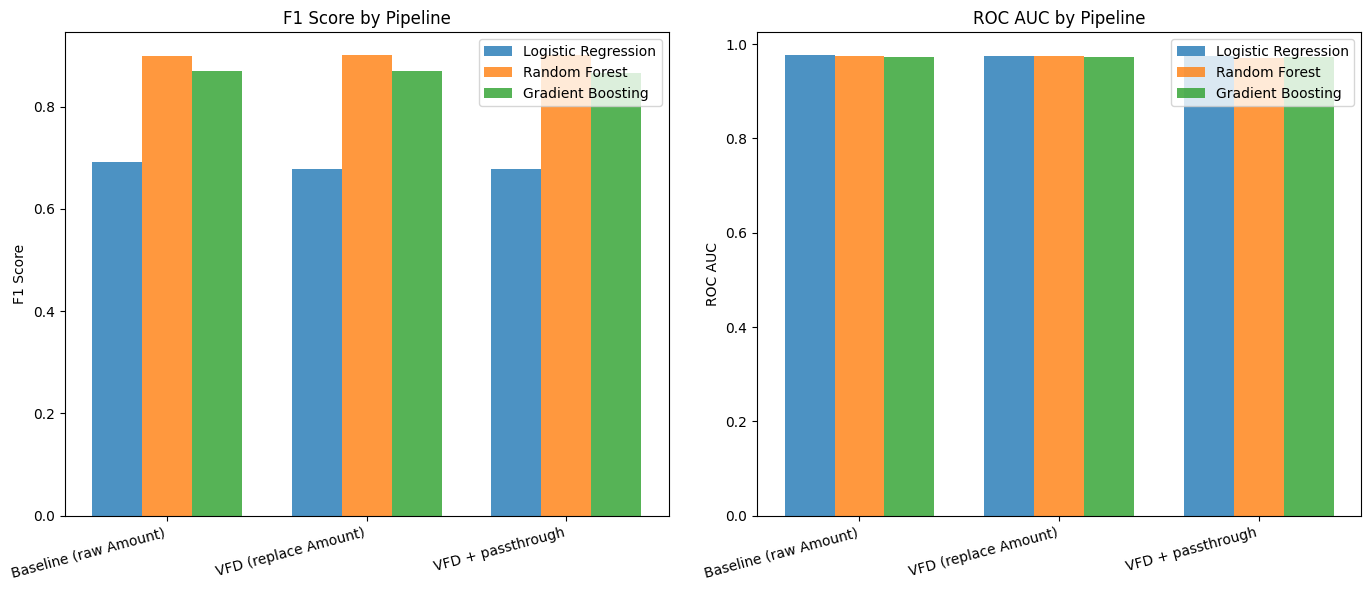

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 comparison
for i, model in enumerate(classifiers.keys()):
    model_results = results_df[results_df['Model'] == model]
    x = np.arange(len(pipelines))
    axes[0].bar(x + i*0.25, model_results['F1_mean'], 0.25, label=model, alpha=0.8)

axes[0].set_xticks(np.arange(len(pipelines)) + 0.25)
axes[0].set_xticklabels(list(pipelines.keys()), rotation=15, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score by Pipeline')
axes[0].legend()

# AUC comparison
for i, model in enumerate(classifiers.keys()):
    model_results = results_df[results_df['Model'] == model]
    x = np.arange(len(pipelines))
    axes[1].bar(x + i*0.25, model_results['AUC_mean'], 0.25, label=model, alpha=0.8)

axes[1].set_xticks(np.arange(len(pipelines)) + 0.25)
axes[1].set_xticklabels(list(pipelines.keys()), rotation=15, ha='right')
axes[1].set_ylabel('ROC AUC')
axes[1].set_title('ROC AUC by Pipeline')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Feature Importance: What VFD Adds

Using a Random Forest to see which VFD features matter most.

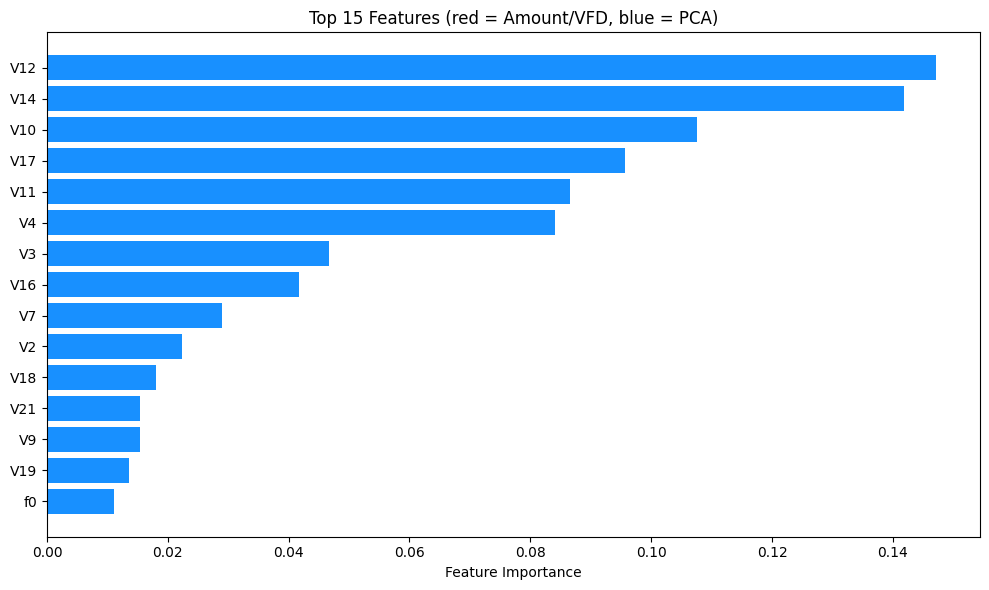


Total VFD feature importance: 0.0162
Raw Amount (passthrough) importance: 0.0000
VFD-only (bars/dots) importance: 0.0162


In [11]:
# Train RF with VFD passthrough and get feature importances
pipe_rf = Pipeline([
    ('encode', ColumnTransformer([
        ('pca', 'passthrough', list(range(28))),
        ('vfd', VFDEncoder(n_levels=3, handle_float='scale', passthrough=True), [28]),
    ])),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
])
pipe_rf.fit(X, y)

# Get feature names
vfd_enc = pipe_rf.named_steps['encode'].named_transformers_['vfd']
all_names = pca_cols + list(vfd_enc.get_feature_names_out())
importances = pipe_rf.named_steps['clf'].feature_importances_

# Show top 15
imp_df = pd.DataFrame({'Feature': all_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d4380d' if 'L' in f or 'Amount' in f else '#1890ff' for f in imp_df['Feature']]
ax.barh(range(len(imp_df)), imp_df['Importance'], color=colors)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features (red = Amount/VFD, blue = PCA)')
plt.tight_layout()
plt.show()

# Summarize VFD contribution
vfd_features = [f for f in all_names if 'L' in f or f == 'x0']
vfd_total = sum(importances[all_names.index(f)] for f in vfd_features if f in all_names)
amount_imp = importances[all_names.index('x0')] if 'x0' in all_names else 0
print(f"\nTotal VFD feature importance: {vfd_total:.4f}")
print(f"Raw Amount (passthrough) importance: {amount_imp:.4f}")
print(f"VFD-only (bars/dots) importance: {vfd_total - amount_imp:.4f}")

## 8. Amount-Only Model: Isolating VFD's Contribution

To truly see VFD's impact, let's build a model using **only** the Amount feature — comparing raw vs VFD.

In [12]:
X_amount = df[['Amount']].values

amount_pipelines = {
    'Raw Amount': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
    'VFD Amount': Pipeline([
        ('vfd', VFDEncoder(n_levels=3, handle_float='scale', passthrough=True)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
}

print("Amount-Only Fraud Detection (Logistic Regression)")
print("=" * 55)
for name, pipe in amount_pipelines.items():
    scores = cross_validate(pipe, X_amount, y, cv=cv, scoring=['f1', 'roc_auc'])
    print(f"{name:15s}  F1={scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}  "
          f"AUC={scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")

Amount-Only Fraud Detection (Logistic Regression)
Raw Amount       F1=0.0777 ± 0.0119  AUC=0.4449 ± 0.0259
VFD Amount       F1=0.0953 ± 0.0087  AUC=0.6392 ± 0.0400


## Conclusions

**Key findings:**

1. **VFD decomposition of transaction amounts provides multi-scale features** that capture rounding patterns, psychological price thresholds, and ATM-multiple structure that raw amounts hide.

2. **For linear models**, VFD consistently improves fraud detection by giving the model access to non-linear amount patterns (crossing \$100/\$200 thresholds, unusual remainders mod 5/20).

3. **For tree models**, use `passthrough=True` to keep the raw Amount alongside VFD features — trees already handle thresholds well and need the original signal.

4. **The amount-only comparison** isolates VFD's contribution — going from 1 feature to 10+ multi-scale features for the same underlying data.

**Use cases this generalizes to:**
- Anti-money laundering (AML) — unusual amount patterns in wire transfers
- Insurance claim fraud — claim amounts with suspicious rounding patterns
- E-commerce fraud — purchase amounts that deviate from typical consumer behavior

### Install

```bash
pip install maya-encoding
```

**Documentation:** [danielregaladoumiami.github.io/maya-encoding](https://danielregaladoumiami.github.io/maya-encoding/)